In [1]:
# Import & Setup

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")

In [2]:
# Task 1: Load and Explore the Data

print(df.head())
print(df.shape)
print(df.describe())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


1. Chargest has the largest range of values.
2. Age and BMI have the most similar scale.
3. Charges, because it is so large compared to the other values, will overpower the other columns.

c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Text(0, 0.5, 'BMI')

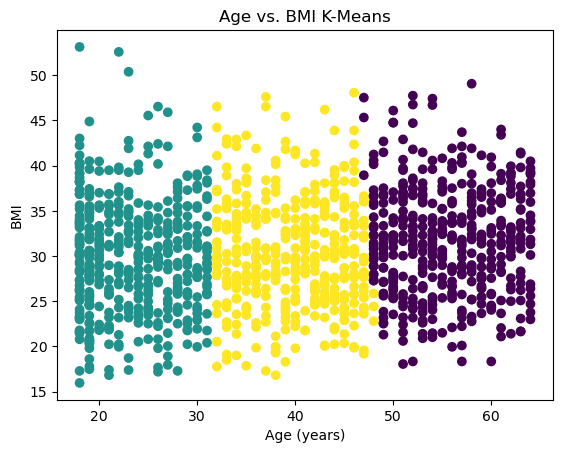

In [3]:
# Task 2: Fit Your First K-Means Model

X = df[['age', 'bmi']]

km = KMeans(n_clusters=3, random_state=42, n_init=10)

df['cluster'] = km.fit_predict(X)
plt.scatter(
    x=df['age'],
    y=df['bmi'],
    c=df['cluster']
)

plt.title('Age vs. BMI K-Means')
plt.xlabel('Age (years)')
plt.ylabel('BMI')

# The grouping isn't very meaningful because the pattern doesn't really change between the groups

c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Text(0, 0.5, 'Charges (USD)')

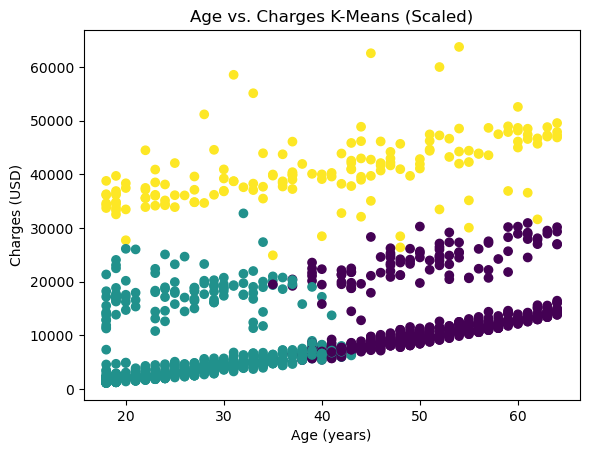

In [4]:
# Task 3: Scale the Features and Refit

X = df[['age', 'bmi', 'charges']]

X_scaled = StandardScaler().fit_transform(X)

df['cluster_scaled'] = km.fit_predict(X_scaled)
plt.scatter(
    x=df['age'],
    y=df['charges'],
    c=df['cluster_scaled']
)

plt.title('Age vs. Charges K-Means (Scaled)')
plt.xlabel('Age (years)')
plt.ylabel('Charges (USD)')

In [5]:
# Task 4: Choose k With the Elbow Method

inertias = []
for k in range(1,10):
    km= KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

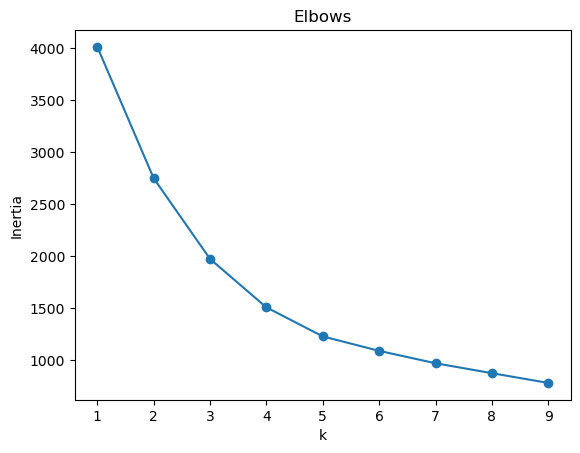

In [6]:
plt.plot(range(1,10), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbows")
plt.show()

The Elbow appears to be at 4.  This is where increasing the K value becomes less impactful. It is a good indicator of how many clusters your model should have.  


## Task 5 Silhouette Score

In [7]:
sil_score = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_score.append({
        'k': k,
        'silhouette_score': silhouette_score(X_scaled, labels)
    })

sil_df = pd.DataFrame(sil_score)
sil_df


c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

,k,silhouette_score
0,2,0.306536
1,3,0.347408
2,4,0.337941
3,5,0.321071
4,6,0.309298
5,7,0.301926
6,8,0.307543
7,9,0.297081


In [8]:
sil_df['silhouette_score'].max()

0.3474083833871619

Based on the max sil score, 3 is our best k value

The silhouette score is grading how well the points fit into their clusters compared to other clusters. It evaluates the quality of clustering.  
a: the average distance to all other points in the same cluster  
b: average distance to points in nearest other cluster  
If it sits below 0 that point may belong in another cluster.  


## Task 6 Describe the Cluster  

In [9]:
km_best = KMeans(n_clusters=3, random_state=42, n_init=10)

df['best_labels'] = km_best.fit_predict(X_scaled)

cluster_means= df.groupby('best_labels')[['age','bmi','charges']].mean()
cluster_means

c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


,age,bmi,charges
best_labels,,,
0,51.604895,31.113444,12786.560845
1,27.330579,29.015777,6425.083510
2,39.788820,35.255839,40712.650088


Cluster 0 has the oldest patients with lower charges.  
Cluster 1 has low charges and moderate BMI and age  
Cluster 2 has the highest charges with a higher BMI  

This could be useful for an insurance company because they separate the groups by cost and life factors  

## A. Task 7 - Add a second dataset

In [ ]:
bike_df = pd.read_csv('bike_sharing.csv')

bike_X = bike_df[['temp', 'hum', 'windspeed', 'casual', 'registered']]

bike_X_scaled = StandardScaler().fit_transform(bike_X)



c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

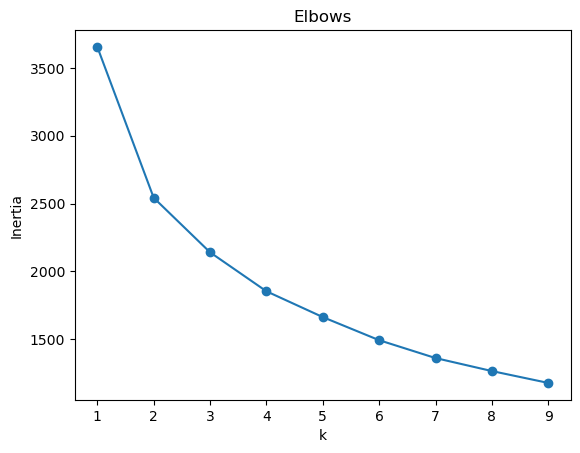

In [15]:
# Elbows
inertias = []
for k in range(1,10):
    km= KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(bike_X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(1,10), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbows")
plt.show()

In [16]:
sil_score = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(bike_X_scaled)
    sil_score.append({
        'k': k,
        'silhouette_score': silhouette_score(bike_X_scaled, labels)
    })

sil_df = pd.DataFrame(sil_score)
sil_df

c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

,k,silhouette_score
0,2,0.274148
1,3,0.233532
2,4,0.229368
3,5,0.227993
4,6,0.213592
5,7,0.221350
6,8,0.220233
7,9,0.227640


In [23]:
km_best = KMeans(n_clusters=2, random_state=42, n_init=10)

bike_df['best_labels'] = km_best.fit_predict(bike_X_scaled)

bike_cluster_means= bike_df.groupby('best_labels')[['temp', 'hum', 'windspeed', 'casual', 'registered']].mean()
bike_cluster_means

c:\Users\Kura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,temp,hum,windspeed,casual,registered
best_labels,,,,,
0,0.340988,0.619736,0.212993,383.387283,2628.338150
1,0.634142,0.635226,0.170260,1265.883117,4579.888312


Cluster 0 is less casual and registered riders. The day is colder.
Cluster 1 is more casual and more registered, being more popular among the two. The day is warmer.

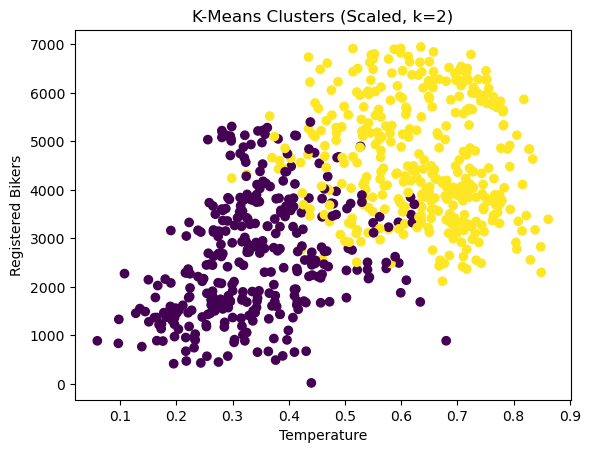

In [24]:
bike_df['cluster'] = km_best.labels_

plt.scatter(
    bike_df['temp'],
    bike_df['registered'],
    c=bike_df['cluster'],
    cmap='viridis'
)

plt.xlabel('Temperature')
plt.ylabel('Registered Bikers')
plt.title('K-Means Clusters (Scaled, k=2)')

plt.show()

# Task 8. DBSCAN

[ 0  1 -1]


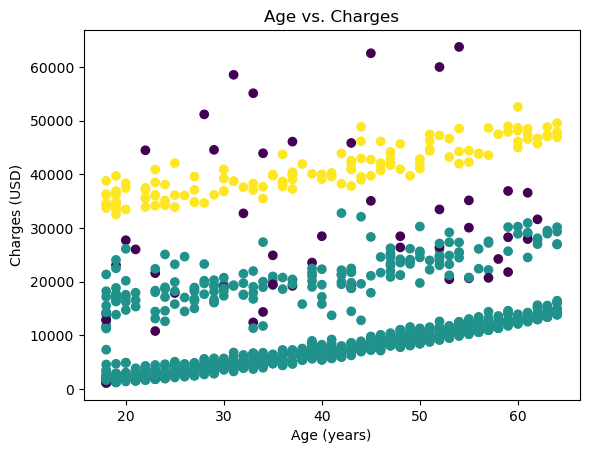

In [28]:
db = DBSCAN(eps=0.5, min_samples=5)
db.fit(X_scaled)

df['cluster_dbscan'] = db.labels_

print(df['cluster_dbscan'].unique())

plt.scatter(
    df['age'],
    df['charges'],
    c=df['cluster_dbscan'],
    cmap='viridis'
)

plt.title('Age vs. Charges')
plt.xlabel('Age (years)')
plt.ylabel('Charges (USD)')
plt.show()

KMeans is a little more interpretable. DBSCAN looks to have grouped them into two distinct groups of charges. KMeans does the same, also grouped the lower charges group by age. Neither is particularly better, it depends on what kind of groupings are most useful to the analysis.